In [ ]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))  # go up two levels (from numerics to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# # Ensure packages are installed
# for pkg in [
#     "PauliPropagation", "Plots", "LinearAlgebra", "ProgressMeter", "Distributions",
#     "Random", "Optimisers", "ReverseDiff", "MAT", "BenchmarkTools", "IterTools", "StatsBase", "LaTeXStrings", "Measures"
# ]
#     Pkg.add(pkg)
# end

In [2]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures

## Target state

In [3]:
nq = 6 
target_jz = 0.346
target_bx = 0.822
target_tfim_paulis = maketfim(nq, jz=target_jz, bx=target_bx)
target_tfim_matrix = paulistringtomatrix(target_tfim_paulis);

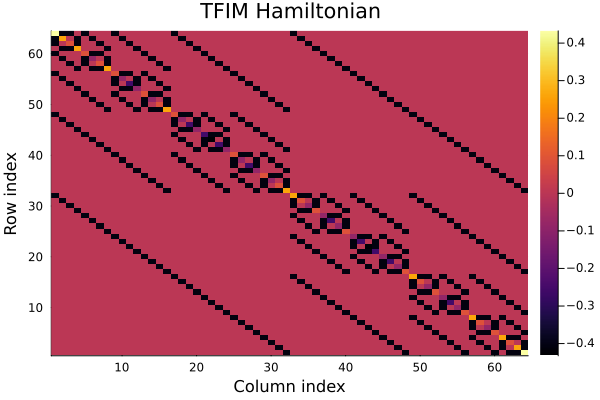

In [4]:
heatmap(reverse(real(target_tfim_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="TFIM Hamiltonian"
        )

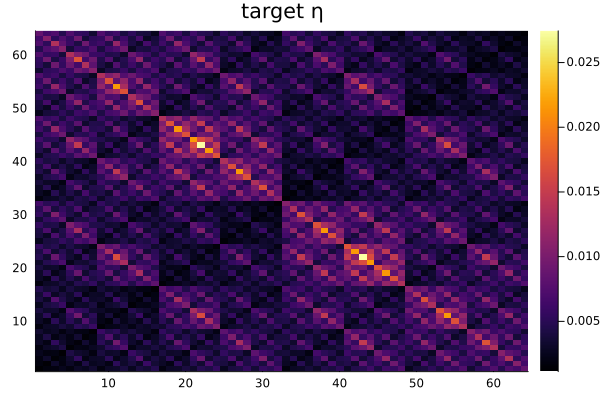

In [6]:
targert_circuit, θ = paulistringtocircuit(target_tfim_paulis)

num_layers = 100
target_beta = 2.
max_weight = nq
min_abs_coeff = 1e-20
target_eta = makethermalstate(nq, targert_circuit, θ, num_layers;
                                  beta=target_beta, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
target_eta_matrix = paulistringtomatrix(target_eta)

heatmap(reverse(real(target_eta_matrix); dims=1), title="target η")

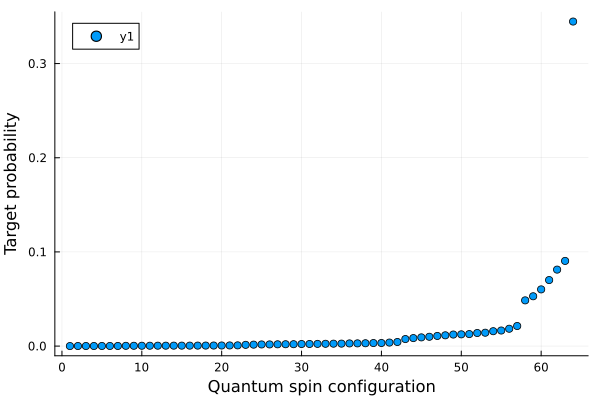

In [7]:
target_probs = computesymmetriceigenvalues(target_eta_matrix);
scatter(target_probs, ylabel="Target probability", xlabel="Quantum spin configuration")

## Model QBM

In [8]:
# parameters to learn. Set initial values at random
rng = MersenneTwister(1)
jz = randn(rng)
bx = randn(rng)
@printf("Spin interaction: %.3f\n", jz)
@printf("Field value: %.3f\n", bx)

Spin interaction: -0.137
Field value: 0.960


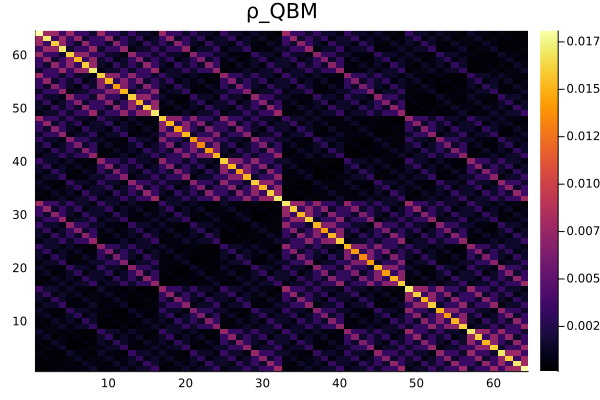

In [9]:
qbm_tfim_paulis = maketfim(nq, jz=jz, bx=bx)
qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)

circuit, params = paulistringtocircuit(qbm_tfim_paulis)

num_layers = 100
beta = 1.
max_weight = nq
min_abs_coeff = 1e-10
qbm = makethermalstate(nq, circuit, params, num_layers;
                                  beta=beta, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
qbm_matrix = paulistringtomatrix(qbm)

heatmap(reverse(real(qbm_matrix); dims=1), title="ρ_QBM")

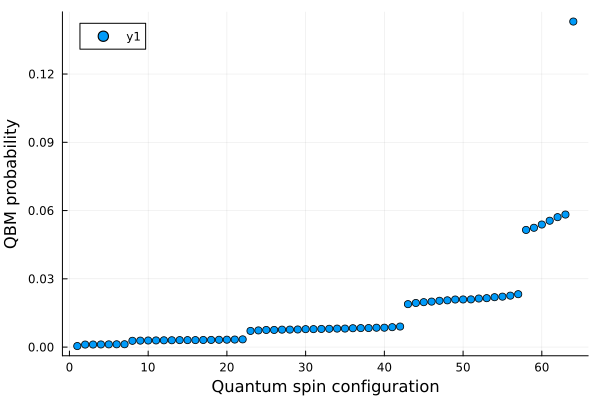

In [10]:
rho_probs = computesymmetriceigenvalues(qbm_matrix)
scatter(rho_probs, marker=:circle, ylabel="QBM probability", xlabel="Quantum spin configuration")

## Cost function: quantum relative entropy

$$S(\eta \| \rho_\theta) = \operatorname{Tr}[\eta \log \eta]-\operatorname{Tr}\left[\eta \log \rho_\theta\right]$$

In [11]:
computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_tfim_matrix)

0.2802475057284006

### Gradient of quantum relative entropy

Given $H_\theta = \sum_i \theta_i H_i$ and the QBM $\rho_\theta = \frac{e^{-\beta H_\theta}}{\operatorname{Tr}[e^{-\beta H_\theta}]}$, the gradient of the cost function (quantum relative entropy) is given by

$$\partial_{\theta_i} S(\eta \| \rho_\theta) = \operatorname{Tr}[H_i \eta] -  \operatorname{Tr}[H_i \rho_\theta]$$

(see Eq. (8) in Tüysüz, Cenk, et al. "Learning to generate high-dimensional distributions with low-dimensional quantum Boltzmann machines." arXiv preprint arXiv:2410.16363 (2024))

In [12]:
gradients = computegradient(qbm_tfim_paulis, target_eta, qbm)
println("Gradients: ", gradients)

Gradients: [0.11303725617437432, 0.11114445716200094, 0.11114059189061484, 0.11114059189066963, 0.11114445716214857, 0.11303725617462157, -0.03670004835275805, -0.03674388111801681, -0.03674396865543506, -0.03674388111808872, -0.03670004835277178]


# Training of the QBM 

In [13]:
# learning rate
gamma = 0.2

0.2

In [14]:
println("Old relative entropy: ", computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_tfim_matrix))

Old relative entropy: 0.2802475057284006


In [15]:
# initialize the QBM with the fixed parameters
old_coeff = [h.coeff for h in qbm_tfim_paulis]
grads = computegradient(qbm_tfim_paulis, target_eta, qbm)
new_params = gradientdescentstep(old_coeff, grads, gamma)
println("Old params: ", old_coeff)
println("New params: ", new_params)

Old params: [-0.4800307807065111, -0.4800307807065111, -0.4800307807065111, -0.4800307807065111, -0.4800307807065111, -0.4800307807065111, -0.034228854604860665, -0.034228854604860665, -0.034228854604860665, -0.034228854604860665, -0.034228854604860665]
New params: [-0.502638231941386, -0.5022596721389113, -0.5022588990846341, -0.502258899084645, -0.5022596721389408, -0.5026382319414354, -0.026888844934309056, -0.0268800783812573, -0.02688006087377365, -0.02688007838124292, -0.026888844934306308]


In [16]:
# the new relative entropy should be lower!
new_qbm_tfim_paulis = maketfim(nq, coeffs=new_params)
new_qbm_tfim_matrix = paulistringtomatrix(new_qbm_tfim_paulis)
println("New relative entropy: ", computequantumrelativeentropy(target_eta_matrix, target_probs, new_qbm_tfim_matrix))

New relative entropy: 0.24618587650648838


Training

In [17]:
# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-6
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

new_params = rand(length(target_tfim_paulis))

epochs = 200

for i in 1:epochs

    # create qbm hamiltonian
    qbm_tfim = maketfim(nq; coeffs=new_params)
    qbm_tfim_matrix = paulistringtomatrix(qbm_tfim)
    push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_tfim_matrix))

    # create qbm state
    circuit, θ = paulistringtocircuit(qbm_tfim)
    num_layers = 100
    beta = 1.
    max_weight = 5
    min_abs_coeff = 1e-10
    rho = makethermalstate(nq, circuit, θ, num_layers;
                                    beta=beta, max_weight=max_weight,
                                    min_abs_coeff=min_abs_coeff)
    rho_matrix = paulistringtomatrix(rho)

    # grad and update
    grads = computegradient(qbm_tfim, target_eta, rho)
    push!(grad_hist, abs.(grads))
    new_params = gradientdescentstep(new_params, grads, gamma)

    # print diagnostic
    if (i % 10) == 0
        @printf("Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("Max abs gradient: %.6f\n", maximum(grad_hist[end]))
    end
    if maximum(grad_hist[end]) < epsilon
        println("Max gradient smaller than precision")
        break
    end
end 

Quantum relative entropy: 0.692602
Max abs gradient: 0.206183
Quantum relative entropy: 0.171623
Max abs gradient: 0.086693
Quantum relative entropy: 0.053662
Max abs gradient: 0.042385
Quantum relative entropy: 0.019761
Max abs gradient: 0.026915
Quantum relative entropy: 0.008195
Max abs gradient: 0.018472
Quantum relative entropy: 0.003702
Max abs gradient: 0.012913
Quantum relative entropy: 0.001773
Max abs gradient: 0.009125
Quantum relative entropy: 0.000883
Max abs gradient: 0.006490
Quantum relative entropy: 0.000451
Max abs gradient: 0.004635
Quantum relative entropy: 0.000235
Max abs gradient: 0.003318
Quantum relative entropy: 0.000124
Max abs gradient: 0.002379
Quantum relative entropy: 0.000066
Max abs gradient: 0.001708
Quantum relative entropy: 0.000036
Max abs gradient: 0.001228
Quantum relative entropy: 0.000020
Max abs gradient: 0.000883
Quantum relative entropy: 0.000012
Max abs gradient: 0.000635
Quantum relative entropy: 0.000007
Max abs gradient: 0.000457
Quantum 

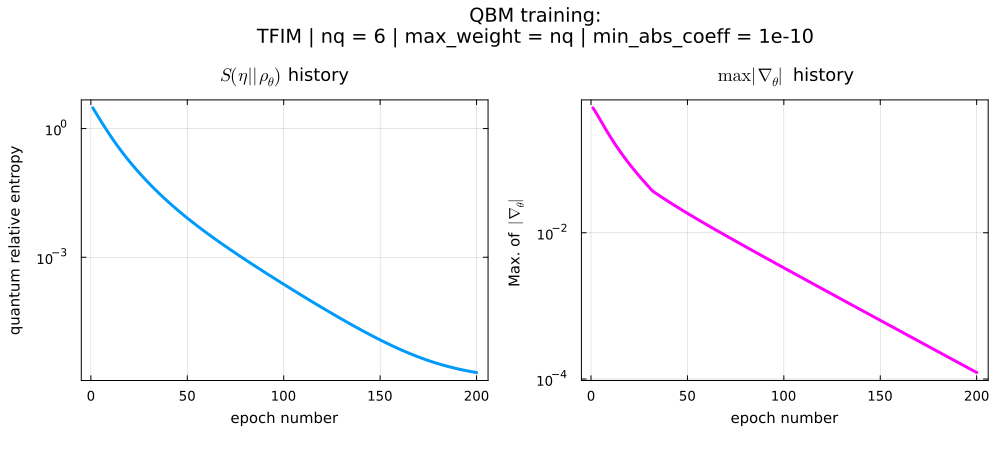

In [18]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training:\nTFIM | nq = 6 | max_weight = nq | min_abs_coeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)


## Compare the final parameters with the target parameters.

**Note** the Hamiltonian is the same but the target state was created with $\beta = 2 $ and we use a QBM with $\beta = -1$.

In [19]:
@printf("Original target parameters:\n Jz=%.6f Bx=%.6f\n", target_jz, target_bx)

Original target parameters:
 Jz=0.346000 Bx=0.822000


In [26]:
qbm_jz, qbm_bx = (new_params[7] * target_beta, - new_params[1])
@printf("Trained QBM parameters:\n Jz=%.6f Bx=%.6f\n", qbm_jz, qbm_bx)

Trained QBM parameters:
 Jz=0.347141 Bx=0.822253


In [29]:
# percentage relative difference
@printf("Relative difference:\n Jz=%.2f%% Bx=%.2f%%\n",
        100*(abs(target_jz - qbm_jz))/target_jz,
        100*(abs(target_bx - qbm_bx))/target_bx)

Relative difference:
 Jz=0.33% Bx=0.03%


Compare the "images" of the target and trained QBM density matrices

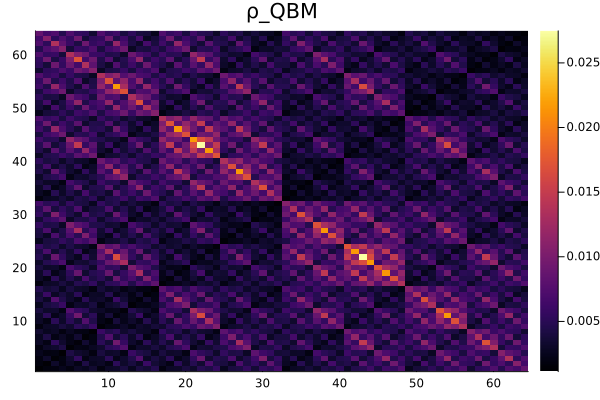

In [30]:
qbm_tfim_paulis = maketfim(nq, coeffs=new_params)
qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)

circuit, params = paulistringtocircuit(qbm_tfim_paulis)

num_layers = 100
beta = 1.
max_weight = nq
min_abs_coeff = 1e-10
qbm = makethermalstate(nq, circuit, params, num_layers;
                                  beta=beta, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
qbm_matrix = paulistringtomatrix(qbm)

heatmap(reverse(real(qbm_matrix); dims=1), title="ρ_QBM")

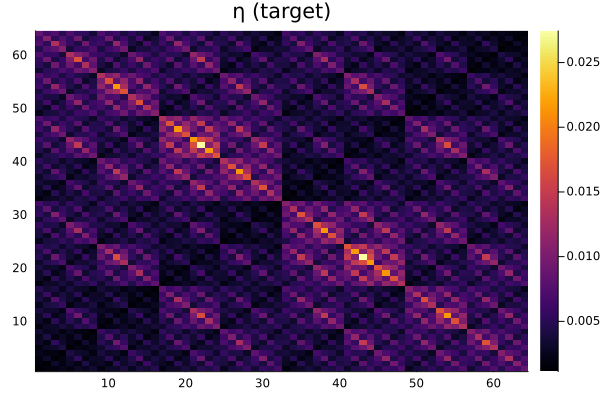

In [31]:
heatmap(reverse(real(target_eta_matrix); dims=1), title="η (target)")

A way to compare the two density matrices is to compute the fidelity between them. A fidelity close to 1 means the two quantum states are the same

In [34]:
# Uhlmann fidelity (squared) between density matrices
function fidelity(ρ::AbstractMatrix, σ::AbstractMatrix)
    F = 0.0
    # sqrt(ρ)
    evals, evecs = eigen(Hermitian(ρ))
    sqrtρ = evecs * Diagonal(sqrt.(clamp.(evals, 0, Inf))) * evecs'
    A = sqrtρ * σ * sqrtρ
    evalsA = computesymmetriceigenvalues(A)
    rootF = sum(sqrt.(clamp.(evalsA, 0, Inf)))
    (rootF)^2
end

fidelity (generic function with 1 method)

In [35]:
# fidelity
F = fidelity(target_eta_matrix, qbm_matrix)
F

0.9999998044939602

We can also plot the probability distributions:

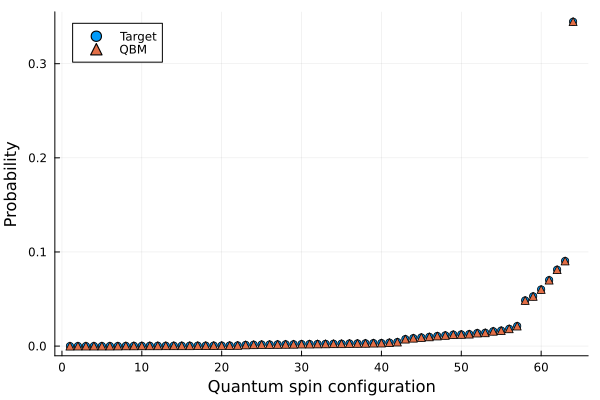

In [36]:
rho_probs = computesymmetriceigenvalues(qbm_matrix)
scatter(1:length(rho_probs), target_probs, label="Target", marker=:circle, xlabel="Quantum spin configuration", ylabel="Probability")
scatter!(1:length(rho_probs), rho_probs, label="QBM", marker=:utriangle)